# 6. 학습 관련 기술들
이번 장의 주제는 가중치 매개변수의 최적값을 탐색하는 최적화 방법, 가중치 매개변수 초깃값, 하이퍼파라미터 설정 방법 등\
과대적합의 대응책인 가중치 감소와 드롭아웃 등의 정규화 방법, 배치 정규화도 살펴봄

## 6.1 매개변수 갱신
신경망 학습의 목적은 손실 함수의 값을 가능한 한 낮추는 매개변수를 찾는 것\
이는 곧 매개변수의 최적값을 찾는 문제이며, 이러한 문제를 푸는 작업을 `최적화(optimization)`라 함\
매개변수 공간은 매우 넓고 복잡해서 최적의 솔루션을 쉽게 못 찾기에 신경망 최적화는 어려운 문제임

지금까지 최적의 매개변수 값을 찾는 단서로 매개변수의 기울기(미분)을 이용하였음\
매개변수의 기울기를 구해, 기울어진 방향으로 매개변수 값을 갱신하는 일을 반복하여 점점 최적의 값에 다가감\
이것을 `확률적 경사 하강법(SGD)`라고 하는데 SGD의 단점을 알아본 후 SGD와는 다른 최적화 기법을 살펴봄

### 6.1.1 SGD의 전략
지금 서 있는 장소에서 가장 크게 기울어진 방향으로 가는 것이 SGD의 전략임\
이 일을 반복하면 언젠가 '깊은 곳'에 찾아갈 수 있을지 모르기 때문

### 6.1.2 확률적 경사 하강법(SGD)
SGD의 수식은 다음과 같음
$$
W \leftarrow W - \eta\frac{\partial L}{\partial W}
$$
W는 갱신할 가중치 매개변수고 $\frac{\partial L}{\partial W}$은 W에 대한 손실 함수의 기울기, $\eta$는 학습률인데, 실제로는 0.1이나 0.001과 같은 값을 미리 정해서 사용함\
$\leftarrow$는 우변의 값으로 좌변의 값을 갱신한다는 뜻으로 SGD는 기울어진 방향으로 일정 거리만 가겠다는 단순한 방법

이 SGD를 파이썬 클래스로 구현하면 다음과 같음

In [1]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr*grads[key]

초기화 때 받는 인수인 lr은 learning rate\
이 학습률을 인스턴스 변수로 유지함\
update(params, grads) 메서드는 SGD 과정에서 반복해서 불림\
인수인 params와 ㅎrads는 딕셔너리 변수\
params['W1'], grads['W1'] 등과 같이 각각 가중치 매개변수와 기울기를 저장하고 있음

SGD 클래스를 사용하면 신경망 매개변수의 진행을 다음과 같이 수행함

```python
network = TwoLayerNet(...)
optimizer = SGD()

for i in range(10000):
    ...
    x_batch, t_batch = get_mini_batch(...) # 미니배치
    grads = network.gradient(x_batch, t_batch)
    params = network.params
    optimizer.update(params, grads)
    ...
```
optimizer는 '최적화를 행하는 자'이며 이 코드에서는 SGD()가 그 역할을 함\
매개변수 갱신은 optimizer가 책임지고 수행하니 우리는 optimizer에 매개변수와 기울기 정보만 넘겨주면 됨

이처럼 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋음\
예를 들어 곧이어 소개할 모멘텀이라는 최적화 기법 역시 update(params, grads)라는 공통의 메서드를 갖도록 구현함\
그래서 optimizer = SGD()라는 문장을 optimizer=Momentum()으로 변경하는 것만으로 SGD를 모멘텀으로 바꿀 수 있음

> 대부분의 딥러닝 프레임워크는 다양한 최적화 기법을 구현해 제공하며, 원하는 기법으로 쉽게 바꿀 수 있는 구조로 되어 있음

### 6.1.3 SGD의 단점
SGD는 단순하고 구현도 쉽지만, 문제에 따라서는 비효율적일 때가 존재함\
SGD의 단점을 알아보고자 다음 함수의 최솟값을 구하는 문제를 생각해 보자
$$
f(x, y) = \frac{1}{20}x^2+y^2
$$
이 함수는 y축 방향의 기울기는 크고 x축 방향의 기울기는 작다는 특징이 있음\
말하자면 y축 방향은 가파른데 x축 방향은 완만하며, 최솟값이 되는 장소는 (x,y)=(0,0)이지만, 기울기 대부분은 (0,0) 방향을 가리키지 않음

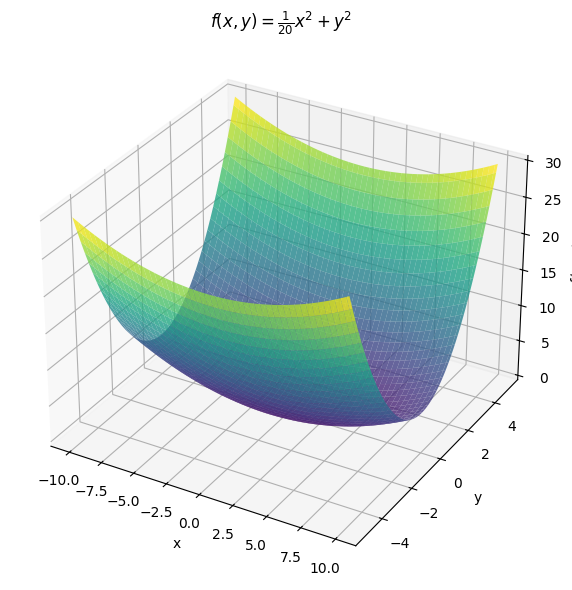

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = (1/20) * X**2 + Y**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title(r'$f(x, y) = \frac{1}{20}x^2+y^2$')
plt.tight_layout()
plt.show()

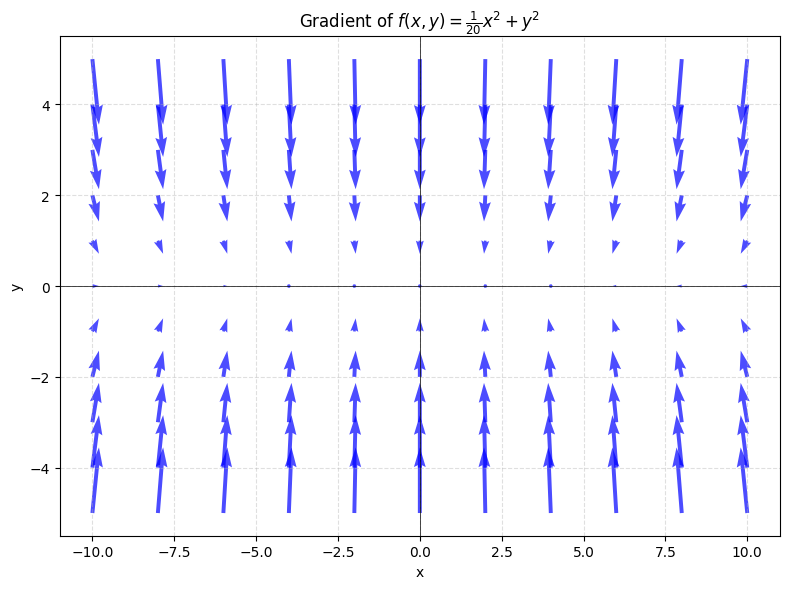

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-10, 11, 2, dtype=float)
y = np.arange(-5, 6, 1, dtype=float)
X, Y = np.meshgrid(x, y)

dX = X / 10 # ∂f/∂x = x/10
dY = 2 * Y # ∂f/∂y = 2y

plt.figure(figsize=(8, 6))
plt.quiver(X, Y, -dX, -dY, color='blue', alpha=0.7) # 음의 기울기 방향 (최솟값 방향)
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Gradient of $f(x, y) = \frac{1}{20}x^2+y^2$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

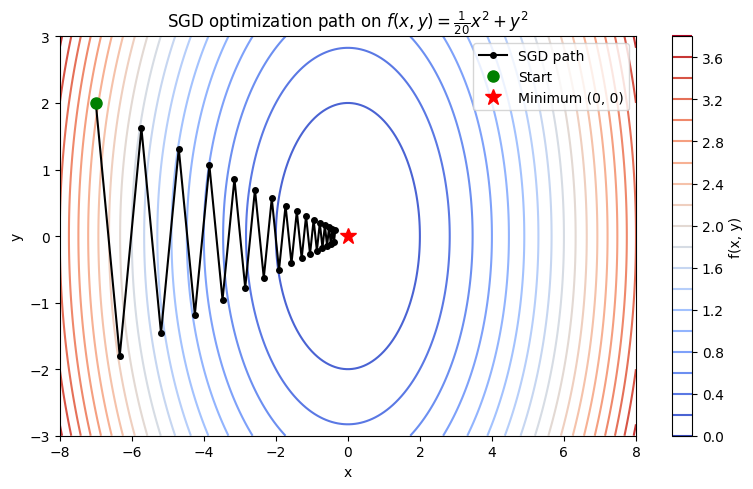

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (1/20) * (x**2 + y**2)

def grad_f(x, y):
    return x / 10, 2 * y # ∂f/∂x, ∂f/∂y

# SGD 경로 추적
lr = 0.95
x, y = -7.0, 2.0
path = [(x, y)]

for _ in range(30):
    gx, gy = grad_f(x, y)
    x -= lr * gx
    y -= lr * gy
    path.append((x, y))

path = np.array(path)

X_grid = np.linspace(-8, 8, 200)
Y_grid = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(X_grid, Y_grid)
Z_grid = f(X_grid, Y_grid)

plt.figure(figsize=(8, 5))
plt.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
plt.colorbar(label='f(x, y)')
plt.plot(path[:, 0], path[:, 1], 'o-', color='black', markersize=4, label='SGD path')
plt.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Start')
plt.plot(0, 0, 'r*', markersize=12, label='Minimum (0, 0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'SGD optimization path on $f(x, y) = \frac{1}{20}x^2+y^2$')
plt.legend()
plt.tight_layout()
plt.show()

SGD는 위 그림처럼 심하게 굽이진 움직임을 보여주며 상당히 비효율적인 움직임을 가짐\
즉, SGD의 단점은 비등방성(anisotropy) 함수(방향에 따라 성질, 즉 여기에서는 기울기가 달라지는 함수)에서는 탐색 경로가 비효율적\
이럴 때는 SGD 같이 무작정 기울어진 방향으로 진행하는 단순한 방식보다 더 영리한 묘안이 필요함\
또한 SGD가 지그재그로 탐색하는 근본 원인은 기울어진 방향이 본래의 최솟값과 다른 방향을 가리켜서라는 점도 생각해볼 필요가 있음

이제 SGD의 단점을 개선해주는 모멘텀, AdaGrad, Adam이라는 세 방법을 소개할 것

### 6.1.4 모멘텀
`모멘텀(momentum)`은 '운동량'을 뜻하는 단어로, 물리와 관계가 있음\
모멘텀 기법은 수식으로는 다음과 같음
$$
v \leftarrow \alpha v - \eta\frac{\partial L}{\partial W} \\[10pt]
W \leftarrow W + v
$$
W는 갱신할 가중치 매개변수, $\frac{\partial L}{\partial W}$ 은 W에 대한 손실 함수의 기울기 $\eta$ 는 학습률\
v는 물리에서 말하는 속도(velocity)에 해당함\
위 식은 기울기 방향으로 힘을 받아 물체가 가속된다는 물리 법칙을 나타내며 그릇의 바닥을 구르는 듯한 움직임을 보여줌

$\alpha v$ 항은 물체가 아무런 힘을 받지 않을 때 서서히 하강시키는 역할을 하며 $\alpha$ 는 0.9 등의 값으로 설정함\
물리에서의 지면 마찰이나 공기 저항에 해당함

다음은 모멘텀의 구현

In [9]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
        
    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

인스턴스 변수 v가 물체의 속도\
v는 초기화 때는 아무 값도 담지 않고, 대신 update()가 처음 호출될 때 매개변수와 같은 구조의 데이터를 딕셔너리 변수로 저장함\
모멘텀의 갱신 경로는 공이 그릇 바닥을 구르듯 움직임\
SGD와 비교하면 지그재그 움직임의 정도가 덜함을 알 수 있음\
이는 x축의 힘은 아주 작지만 방향은 변하지 않아서 한 방향으로 일정하게 가속하기 때문\
반대로 y축의 힘은 크지만 위아래로 번갈아 받아서 상충하여 y축 방향의 속도는 안정적이지 않음\
전체적으로는 SGD보다 x축 방향으로 빠르게 다가가 지그재그 움직임이 줄어들게 됨

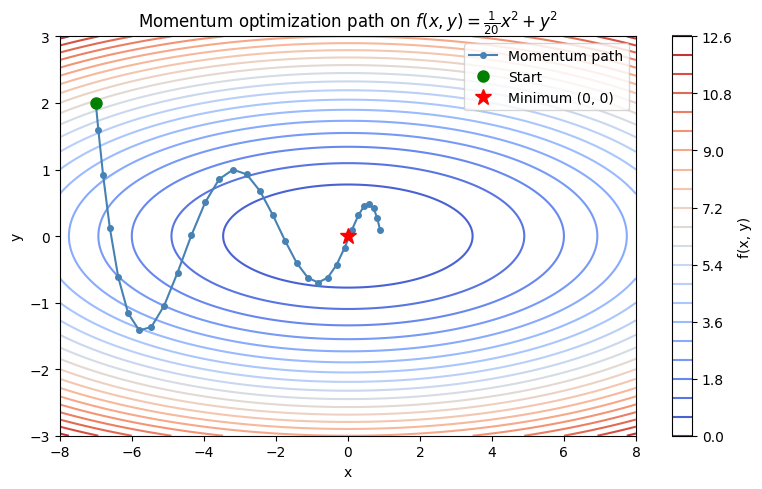

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (1/20) * x**2 + y**2

def grad_f(x, y):
    return x / 10, 2 * y

# 모멘텀 경로 추적
lr = 0.1
alpha = 0.9
x, y = -7.0, 2.0
vx, vy = 0.0, 0.0
path = [(x, y)]

for _ in range(30):
    gx, gy = grad_f(x, y)
    vx = alpha * vx - lr * gx
    vy = alpha * vy - lr * gy
    x += vx
    y += vy
    path.append((x, y))

path = np.array(path)

X_grid = np.linspace(-8, 8, 200)
Y_grid = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(X_grid, Y_grid)
Z_grid = f(X_grid, Y_grid)

plt.figure(figsize=(8, 5))
plt.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
plt.colorbar(label='f(x, y)')
plt.plot(path[:, 0], path[:, 1], 'o-', color='steelblue', markersize=4, label='Momentum path')
plt.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Start')
plt.plot(0, 0, 'r*', markersize=12, label='Minimum (0, 0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Momentum optimization path on $f(x, y) = \frac{1}{20}x^2+y^2$')
plt.legend()
plt.tight_layout()
plt.show()

### 6.1.5 AdaGrad
신경망 학습에서는 학습률(수식에서 $\eta$로 표기) 값이 중요한데, 이 값이 너무 작으면 학습 시간이 너무 길어지고, 반대로 너무 크면 발산하여 학습이 제대로 이뤄지지 않음

이 학습률을 정하는 효과적 기술로 `학습률 감소(learning rate decay)`가 있음\
이는 학습을 진행하면서 학습률을 점차 줄여가는 방법인데, 처음에는 크게 학습하다가 조금씩 작게 학습한다는 것으로 실제 신경망 학습에 자주 쓰임\
학습률을 서서히 낮추는 가장 간단한 방법은 매개변수 '전체'의 학습률 값을 일괄적으로 낮추는 것\
이를 더욱 발전시킨 기법이 AdaGrad\
AdaGrad는 '각각의' 매개변수에 '맞춤형' 값을 만들어줌

AdaGrad는 개별 매개변수에 적응적으로(adaptive) 학습률을 조정하면서 학습을 진행함\
AdaGrad의 갱신 방법의 수식은 다음과 같음
$$
h \leftarrow h + \frac{\partial L}{\partial W} \odot \frac{\partial L}{\partial W} \\[10pt]
W \leftarrow W - \eta \frac{1}{\sqrt{h}} \frac{\partial L}{\partial W}
$$

W는 갱신할 가중치 매개변수, $\frac{\partial L}{\partial W}$ 은 W에 대한 손실 함수의 기울기 $\eta$ 는 학습률\
h는 기존 기울기 값을 제곱하여 계속 더해줌($\odot$ 기호는 행렬의 원소별 곱셈을 의미함)\
매개변수를 갱신할 때 $\frac{1}{\sqrt{h}}$ 을 곱해 학습률을 조정함\
매개변수의 원소 중에서 많이 움직인(크게 갱신된) 원소는 학습률이 낮아진다는 뜻인데, 다시 말해 학습률 감소가 매개변수의 원소마다 다르게 적용됨을 뜻함

> AdaGrad는 과거의 기울기를 제곱하여 계속 더해가기에 학습을 진행할수록 갱신 강도가 약해짐\
실제로 무한히 계속 학습한다면 어느 순간 갱신량이 0이 되어 전혀 갱신되지 않음\
이 문제를 개선한 기법으로서 RMSProp이라는 방법이 존재하는데 이는 과거의 모든 기울기를 균일하게 더해가는 것이 아니라, 먼 과거의 기울기는 서서히 잊고 새로운 기울기 정보를 크게 반영함\
이를 지수이동평균(Exponential Moving Average(EMA))라 하여, 과거 기울기의 반영 규모를 기하급수적으로 감소시킴

AdaGrad의 구현을 살펴봄

In [11]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
    
    def update(self, params, grads):
        if self.h is None:
            self.h ={}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

마지막 줄의 1e-7을 더함으로써 self.h[key]에 0이 담겨 있다 해도 0으로 나누는 사태를 막아줌\
대부분 딥러닝 프레임워크에서는 이 값도 인수로 설정할 수 있음

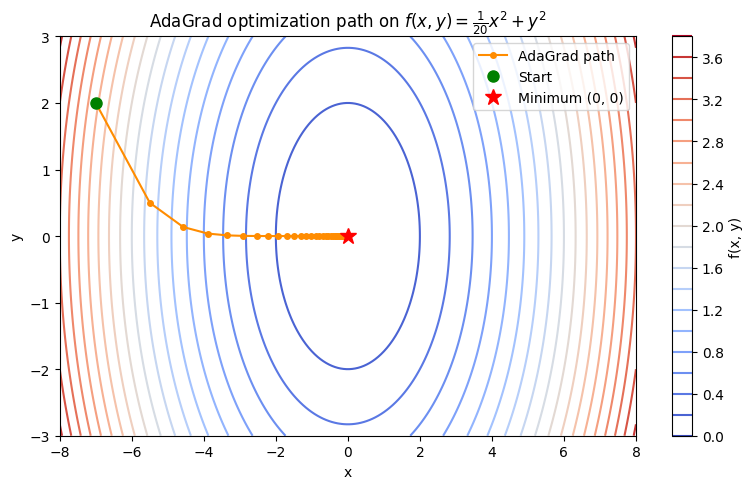

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (1/20) * (x**2 + y**2)

def grad_f(x, y):
    return x / 10, 2 * y

lr = 1.5
x, y = -7.0, 2.0
hx, hy = 0.0, 0.0
eps = 1e-7
path = [(x, y)]

for _ in range(30):
    gx, gy = grad_f(x, y)
    hx += gx ** 2
    hy += gy ** 2
    x -= lr * gx / (np.sqrt(hx) + eps)
    y -= lr * gy / (np.sqrt(hy) + eps)
    path.append((x, y))

path = np.array(path)

X_grid = np.linspace(-8, 8, 200)
Y_grid = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(X_grid, Y_grid)
Z_grid = f(X_grid, Y_grid)

plt.figure(figsize=(8, 5))
plt.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
plt.colorbar(label='f(x, y)')
plt.plot(path[:, 0], path[:, 1], 'o-', color='darkorange', markersize=4, label='AdaGrad path')
plt.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Start')
plt.plot(0, 0, 'r*', markersize=12, label='Minimum (0, 0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'AdaGrad optimization path on $f(x, y) = \frac{1}{20}x^2+y^2$')
plt.legend()
plt.tight_layout()
plt.show()

위 그림을 보면 최솟값을 향해 효율적으로 움직이는 모습을 확인할 수 있음\
y축 방향은 기울기가 커서 처음에는 크게 움직이지만, 그 큰 움직임에 비례해 갱신 정도도 큰 폭으로 작아지도록 조정됨\
그래서 y축 방향으로 갱신 강도가 빠르게 약해지고, 지그재그 움직임이 줄어듬

### 6.1.6 Adam
모멘텀은 공이 그릇 바닥을 구르는 듯한 움직임을 보였고 AdaGrad는 매개변수의 원소마다 적응적으로 갱신 정도를 조정하였음\
'이 두 기법을 융합하면?'이라는 생각에서 출발한 기법이 Adam

Adam은 2015년에 제안된 방법으로 이론은 다소 복잡하지만, 직관적으로는 모멘텀과 AdaGrad를 융합한 듯한 방법임\
이 두 방법의 이점을 조합했다면 매개변수 공간을 효율적으로 탐색해줄 것으로 기대할 수 있음\
또 하이퍼파라미터의 '편향 보정'이 진행된다는 점도 Adam의 특징\


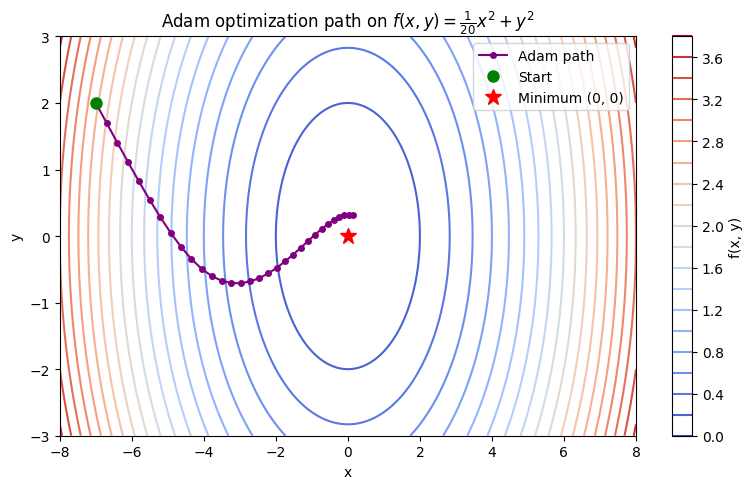

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (1/20) * (x**2 + y**2)

def grad_f(x, y):
    return x / 10, 2 * y

lr = 1.5
x, y = -7.0, 2.0
hx, hy = 0.0, 0.0
eps = 1e-7
path = [(x, y)]

lr = 0.3
beta1, beta2 = 0.9, 0.999
eps = 1e-8
x, y = -7.0, 2.0
mx, my = 0.0, 0.0 # 1차 모멘트
vx, vy = 0.0, 0.0 # 2차 모멘트
path = [(x, y)]

for t in range(1, 31):
    gx, gy = grad_f(x, y)
    mx = beta1 * mx + (1 - beta1) * gx
    my = beta1 * my + (1 - beta1) * gy
    vx = beta2 * vx + (1 - beta2) * gx**2
    vy = beta2 * vy + (1 - beta2) * gy**2
    # 편향 보정
    mx_hat = mx / (1 - beta1**t)
    my_hat = my / (1 - beta1**t)
    vx_hat = vx / (1 - beta2**t)
    vy_hat = vy / (1 - beta2**t)
    x -= lr * mx_hat / (np.sqrt(vx_hat) + eps)
    y -= lr * my_hat / (np.sqrt(vy_hat) + eps)
    path.append((x, y))

path = np.array(path)

X_grid = np.linspace(-8, 8, 200)
Y_grid = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(X_grid, Y_grid)
Z_grid = f(X_grid, Y_grid)

plt.figure(figsize=(8, 5))
plt.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
plt.colorbar(label='f(x, y)')
plt.plot(path[:, 0], path[:, 1], 'o-', color='purple', markersize=4, label='Adam path')
plt.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Start')
plt.plot(0, 0, 'r*', markersize=12, label='Minimum (0, 0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Adam optimization path on $f(x, y) = \frac{1}{20}x^2+y^2$')
plt.legend()
plt.tight_layout()
plt.show()

위 그림과 같이 Adam의 갱신 과정도 그릇 바닥을 구르듯 움직임\
모멘텀과 비슷한 패턴인데, 모멘텀 때보다 공의 좌우 흔들림이 적은데, 이는 학습의 갱신 강도를 적응적으로 조정해서 얻는 혜택

> Adam은 하이퍼파라미터 3개를 설정함\
하나는 학습률, 나머지 두개는 일차 모멘텀용 계수와 이차 모멘텀용 계수며 기본 설정값은 각각 0.9, 0.999이며, 이 값이면 많은 경우에 좋은 결과를 얻을 수 있음

### 6.1.7 어느 갱신 방법을 이용할 것인가?
네 기법의 결과를 보면 사용한 기법에 따라 갱신 경로가 다름\
모든 문제에서 항상 뛰어난 기법은 아직까지는 없으며 풀어야 할 문제가 무엇이냐에 따라 달라지므로 주의해야 함\
학습률과 같은 하이퍼파라미터를 어떻게 설정하느냐에 따라서도 결과가 바뀌게 됨\
많은 연구에서 SGD를 사용하고 있으며 모멘텀과 AdaGrad도 시도해볼 만한 가치가 충분함

## 6.2 가중치의 초깃값
신경망 학습에서는 가중치의 초깃값을 무엇으로 설정하느냐가 신경망 학습의 성패를 가르는 일이 자주 있을 정도로 중요함\

### 6.2.1 초깃값을 0으로 하면?
과대적합을 억제해 범용 성능을 높이는 테크닉인 `가중치 감소(weight decay)` 기법을 소개할 것임\
가중치 감소는 간단히 말하자면 가중치 매개변수의 값이 작아지도록 학습하는 방법이며 가중치 값을 작게하여 과대적합이 일어나지 않게 하는 것

가중치를 작게 만들고 싶으면 초깃값도 최대한 작은 값에서 시작하는 것이 정공법\
지금까지 가중치의 초깃값은 0.01*np.random.randn(10,100)처럼 정규분포에서 생성되는 값을 0.01배한 작은 값을 사용하였음\
하지만 가중치의 초깃값을 모두 0으로 설정하는 것은 학습이 올바로 이뤄지지 않음

초깃값을 모두 0으로 해서는 안 되는 이유는 무엇일까?(정확하게는 가중치를 균일한 값으로 설정해서는 안되는 이유)\
오차역전파법에서 모든 가중치의 값이 똑같이 갱신되기 때문임\
예를 들어 2층 신경망에서 첫 번째와 두 번째 층의 가중치가 0이라고 가정함\
순전파 때는 입력층의 가중치가 0이기 때문에 두 번째 층의 뉴런에 모두 같은 값이 전달됨\
두 번째 층의 모든 뉴런에 같은 값이 입력된다는 것은 역전파 때 두 번째 층의 가중치가 모두 똑같이 갱신된다는 것\
그래서 가중치들은 같은 초깃값에서 시작하고 갱신을 거쳐도 여전히 같은 값을 유지하는데, 이는 가중치를 여러 개 갖는 의미를 사라지게함\
이 '가중치가 고르게 되어버리는 상황'을 막으려면(가중치의 대칭적인 구조를 무너뜨리려면) 초깃값을 무작위로 설정해야 함

### 6.2.2 은닉층의 활성화값 분포
은닉층의 활성화값(활성화 함수의 출력 데이터)의 분포를 관찰하면 중요한 정보를 얻을 수 있음\
가중치의 초깃값에 따라 은닉층 활성화값들이 어떻게 변화하는지 간단한 실험을 해보려 함\
구체적으로는 활서오하 함수로 시그모이드 함수를 사용하는 5층 신경망에 무작위로 생성한 입력 데이터를 흘리며 각 층의 활성화값 분포를 히스토그램으로 그려봄

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

x = np.random.randn(1000, 100) # 1000 개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런 수)
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화값)를 저장

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]
    w = np.random.randn(node_num, node_num) * 1
    a = np.dot(x, w)
    z = sigmoid(a)
    activations[i] = z

층이 5개가 있으며, 각 층의 뉴런은 100개\
입력 데이터로서 1,000개의 데이터를 정규분포로 무작위로 생성하여 이 5층 신경망에 흘림\
활성화 함수로는 시그모이드 함수를 이용했고, 각 층의 활성화 결과를 activations 변수에 저장함\
이 코드에서는 가중치의 분포에 주의해야 함\
이번에는 표준편차가 1인 정규분포를 이용했는데, 이 분포된 정도(표준편차)를 바꿔가며 활성화값들의 분포가 어떻게 변화하는지 관찰\
activations에 저장된 각 층의 활성화값 데이터를 히스토그램으로 그려볼 것임

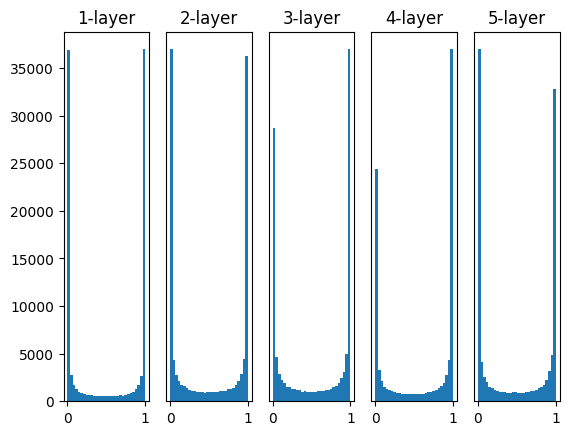

In [18]:
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

각 층의 활성화 값들이 0과 1에 치우쳐 분포되어 있음\
시그모이드 함수는 그 출력이 0 또는 1에 가까워지면 그 미분은 0에 다가감\
그래서 데이터가 0과 1에 치우쳐 분포하게 되면 역전파의 기울기 값이 점점 작아지다가 사라지게 되며 이 현상이 `기울기 소실(gradient vanishing)`이라 알려진 문제임\
층을 깊게 하는 딥러닝에서는 기울기 소실은 더 심각한 문제가 될 수 있음

이번에는 가중치의 표준편차를 0.01로 바꿔 같은 실험을 반복해볼 것임

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

x = np.random.randn(1000, 100) # 1000 개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런 수)
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화값)를 저장

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]
    w = np.random.randn(node_num, node_num) * 0.01
    a = np.dot(x, w)
    z = sigmoid(a)
    activations[i] = z

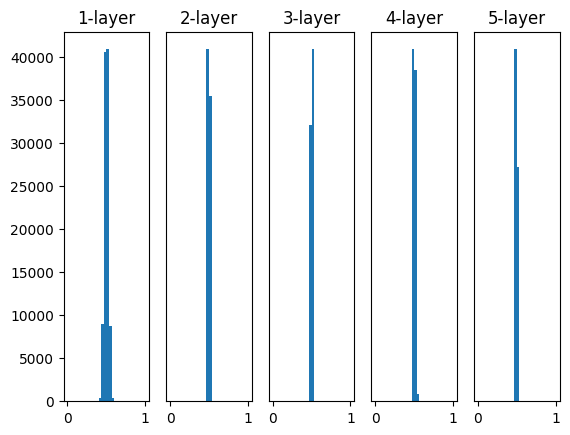

In [20]:
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

이번에는 0.5 부근에 집중되었음\
앞의 예제처럼 0과 1로 치우치진 않았으니 기울기 소실 문제는 일어나지 않지만, 활성화값들이 치우쳤다는 것은 표현력 측면에서는 큰 문제가 있다는 의미\
이 상황에서는 다수의 뉴런이 거의 같은 값을 출력하고 있으니 뉴런을 여러 개 두는 의미가 없어짐\
예를 들어 뉴런 100개가 거의 같은 값을 출력한다면 뉴런 1개짜리와 별반 다를 것이 없음\
그래서 활성화값들이 치우치면 `표현력을 제한`한다는 관점에서 문제가 됨

> 각 층의 활성화값은 적당히 고루 분포되어야 함\
츠오가 층 사이에 적당하게 다양한 데이터가 흐르게 해야 신경망 학습이 효율적으로 이뤄지기 때문\
반대로 치우친 데이터가 흐르면 기울기 소실이나 표현력 제한 문제에 빠져 학습이 잘 이뤄지지 않는 경우가 생김

이어서 사비에르 글로로트와 요슈아 벤지오의 논문에서 권장하는 가중치 초깃값인, `Xavier 초깃값`을 써볼 것임\
현재 Xavier 초깃값은 일반적인 딥러닝 프레임워크들이 표준적으로 이용하고 있음

이 논문은 각 층의 활성화값들을 광범위하게 분포시킬 목적으로 가중치의 적절한 분포를 찾고자 하였음\
그리고 앞 계층의 노드가 n개라면 표준편차가 $\frac{1}{\sqrt{n}}$ 인 분포를 사용하면 된다는 결론을 이끌었음

Xavier 초깃값을 사용하면 앞 층에 노드가 많을수록 대상 노드의 초깃값으로 설정하는 가중치가 좁게 퍼짐

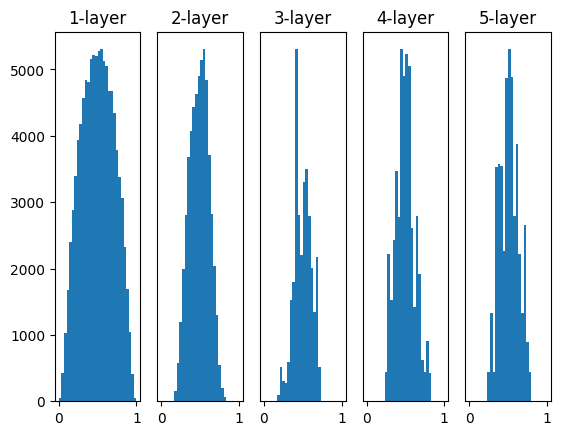

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

x = np.random.randn(1000, 100) # 1000 개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런 수)
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화값)를 저장

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]
    w = np.random.randn(node_num, node_num) / np.sqrt(node_num)
    a = np.dot(x, w)
    z = sigmoid(a)
    activations[i] = z

for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

Xavier 초깃값을 사용한 결과는 위 그림처럼 됨\
이 결과를 보면 츠잉 깊어지면서 형태가 다소 일그러지지만 앞에서 본 방식보다는 확실히 넓게 분포됨을 알 수 있음\
각 층에 흐르는 데이터는 적당히 퍼져 있으므로, 시그모이드 함수의 표현력도 제한받지 않고 학습이 효율적으로 이뤄질 것으로 기대됨

> 위 그림은 오른쪽으로 갈수록 약간씩 일그러지고 있음\
이 일그러짐은 sigmoid 함수 대신 tanh 함수(쌍곡선 함수)를 이용하면 개선됨\
활성화 함수용으로는 원점에서 대칭인 함수가 바람직하다고 알려져 있음

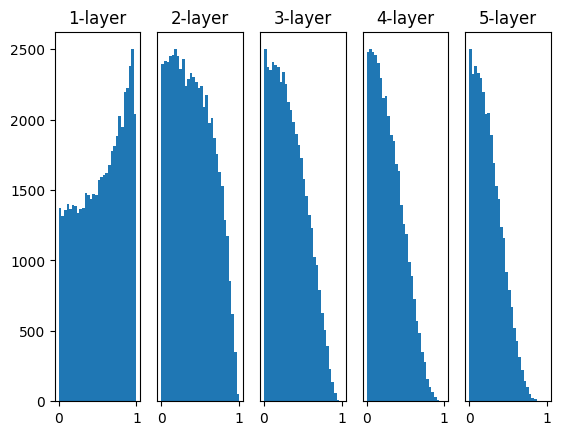

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

x = np.random.randn(1000, 100) # 1000 개의 데이터
node_num = 100 # 각 은닉층의 노드(뉴런 수)
hidden_layer_size = 5 # 은닉층이 5개
activations = {} # 이곳에 활성화 결과(활성화값)를 저장

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]
    w = np.random.randn(node_num, node_num) / np.sqrt(node_num)
    a = np.dot(x, w)
    z = np.tanh(a)
    activations[i] = z

for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

### 6.2.3 ReLU를 사용할 때의 가중치 초깃값
Xavier 초깃값은 활성화 함수가 선형이라는 전제로 이끈 결과임\
sigmoid 함수와 ㅅanh 함수는 좌우 대칭이라 중앙 부근이 선형인 함수로 볼 수 있기에 Xavier 초깃값이 적당함\
ReLU를 이용할 때는 ReLU에 특화된 초깃값을 이용하라고 권장하며 이 특화된 초깃값을 `He 초깃값`이라고 함\
He 초깃값은 앞 계층의 노드가 n개일 때, 표준편차가 $\sqrt{\frac{2}{n}}$ 인 정규분포를 사용함(Xavier 초깃값은 $\sqrt{\frac{1}{n}}$)\
ReLU는 음의 영역이 0이라서 더 넓게 분포시키기 위해 2배의 계수가 필요하다고 해석할 수 있음

## 6.3 배치 정규화
앞 절에서는 각 층의 활성화값 분포를 관찰하며 가중치의 초깃값을 적절히 설정하면 각 층의 활성화값 분포가 적당히 퍼지면서 학습이 원활하게 수행됨을 살펴보았음\
그렇다면 각 층이 활성화를 적당히 퍼뜨리도록 강제해보면 어떨까?\
`배치 정규화(Batch Normalization)`가 그런 아이디어에서 출발한 방법

### 6.3.1 배치 정규화 알고리즘
배치 정규화는 2015년에 제안된 방법으로 많은 연구자와 기술자가 즐겨 사용하고 있음\
배치 정규화가 주목받는 이유는 다음과 같음

* 학습을 빨리 진행할 수 있음(학습 속도 개선)
* 초깃값에 크게 의존하지 않음
* 과대적합을 억제함(드롭아웃 등의 필요성 감소)

배치 정규화의 기본 아이디어는 각 층에서의 활성화값이 적당히 분포되도록 조정하는 것

입력 데이터 $\rightarrow$ Affine $\rightarrow$ Batch Norm $\rightarrow$ ReLU $\rightarrow$ Affine $\rightarrow$ Batch Norm $\rightarrow$ ReLU $\rightarrow$ Affine $\rightarrow$ Softmax $\rightarrow$

배치 정규화는 그 이름과 같이 학습 시 미니 배치를 단위로 정규화함\
구체적으로는 데이터 분포가 평균이 0, 분산이 1이 되도록 정규화 하며 수식은 다음과 같음
$$
\mu_{B} \leftarrow \frac{1}{m}\sum_{i=1}^{m}{x_i} \\[10pt]
\sigma_{B}^2 \leftarrow \frac{1}{m}\sum_{i=1}^{m}{(x_i - \mu_{B})^2} \\[10pt]
\hat{x}_{i} \leftarrow \frac{x_i - \mu_{B}}{\sqrt{\sigma_{B}^{2} + \varepsilon}}
$$
여기에는 미니배치 B = {$x_1, x_2, ..., x_m$}이라는 m개의 입력 데이터의 집합에 대해 평균 $\mu_{B}$ 와 분산 $\sigma_{B}^2$ 을 구함\
그리고 입력 데이터를 평균이 0, 분산이 1이 되게(적절한 분포가 되게) 정규화 함\
위 식에서 $\varepsilon$(엡실론, epsilon) 기호는 작은 값(예컨대 10e-7 등)으로, 0으로 나누는 사태를 예방하는 역할

위 식은 단순히 미니배치 입력 데이터 {$x_1, x_2, ..., x_m$}을 평균 0, 분산 1인 데이터 {$\hat{x_1}, \hat{x_2}, ..., \hat{x_m}$}으로 변환하는 일을 함\
이 처리를 홣성화 함수 앞(혹은 뒤)에 삽입함으로써 데이터 분포가 덜 치우치게 할 수 있음\
또 배치 정규화 계층마다 이 정규화된 데이터에 고유한 확대(scale)와 이동(shift)변환을 수행하며 수식으로는 다음과 같음
$$
y_i \leftarrow \gamma\hat{x_i} + \beta
$$
이 식에서 $\gamma$ 가 확대를 $\beta$ 가 이동을 담당하며, 두 값은 처음에는 $\gamma = 1, \beta = 0$ 부터 시작하고 학습하면서 적합한 값으로 조정해감\
($\gamma = 1$은 1배 확대를 뜻하고 $\beta = 0$은 이동하지 않음을 뜻하여 처음에는 원본 그대로 시작한다는 의미)

## 6.4 바른 학습을 위해
머신러닝에서는 `과대적합`이 문제가 되는 일이 많음\
과대적합이란 신경망이 훈련 데이터에만 지나치게 적응되어 그 외의 데이터에는 제대로 대응하지 못하는 상태를 말함\
머신러닝은 범용 성능을 지향하기에 훈련 데이터에는 포함되지 않는, 아직 보지 못한 데이터가 주어져도 바르게 식별해내야 바람직한 모델\
복잡하고 표현력이 높은 모델을 만들 수는 있지만 그만큼 과대적합을 억제하는 기술이 중요하다는 뜻

### 6.4.1 과대적합
과대적합은 주로 다음의 두 경우에 일어남
* 매개변수가 많고 표현력이 높은 모델
* 훈련 데이터가 적음

이번 절에서는 이 두 요건을 일부러 충족하여 과대적합을 일으켜볼 것임\
본래 60,000개인 MNIST 데이터셋의 훈련 데이터 중 300개만 사용하고, 7층 신경망을 사용해 복잡성을 높일 것이며 각 층의 뉴런은 100개, 활성화 함수는 ReLU를 사용함

먼저 데이터를 읽는 코드는 다음과 같음

In [26]:
# coding: utf-8
import sys, os
# sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '..'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

이어서 훈련을 수행하는 코드이며, 에포크마다 모든 훈련 데이터와 모든 시험 데이터 각각에서 정확도를 산출함

In [27]:
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                        output_size=10)
optimizer = SGD(lr=0.01)  # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + \
            str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break

epoch:0, train acc:0.10666666666666667, test acc:0.1009
epoch:1, train acc:0.11, test acc:0.1005
epoch:2, train acc:0.11666666666666667, test acc:0.1
epoch:3, train acc:0.12, test acc:0.1051
epoch:4, train acc:0.13333333333333333, test acc:0.114
epoch:5, train acc:0.16666666666666666, test acc:0.1249
epoch:6, train acc:0.2, test acc:0.1445
epoch:7, train acc:0.22333333333333333, test acc:0.1625
epoch:8, train acc:0.2733333333333333, test acc:0.1842
epoch:9, train acc:0.31, test acc:0.2043
epoch:10, train acc:0.32, test acc:0.2249
epoch:11, train acc:0.3566666666666667, test acc:0.2521
epoch:12, train acc:0.37, test acc:0.2709
epoch:13, train acc:0.38, test acc:0.2796
epoch:14, train acc:0.38, test acc:0.295
epoch:15, train acc:0.4, test acc:0.3063
epoch:16, train acc:0.42333333333333334, test acc:0.3185
epoch:17, train acc:0.42, test acc:0.3186
epoch:18, train acc:0.43666666666666665, test acc:0.3236
epoch:19, train acc:0.44333333333333336, test acc:0.3329
epoch:20, train acc:0.4533333

train_acc_list와 test_acc_list에는 에포크 단위(모든 훈련 데이터를 한 번씩 본 단위)의 정확도를 저장함\
이 두 리스트를 그래프로 그리면 아래와 같음

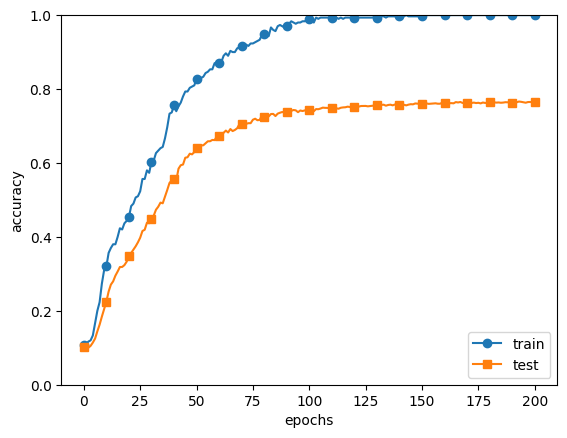

In [28]:
# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

훈련 데이터를 사용하여 측정한 정확도는 100 에포크를 지나는 무렵부터 거의 100%임\
그러나 시험 데이터에 대해서는 큰 차이를 보이는데, 이처럼 정확도가 크게 벌어지는 것은 훈련 데이터에만 적응(fitting)해버린 결과\
훈련 때 사용하지 않은 범용 데이터(시험 데이터)에는 제대로 대응하지 못한다는 사실을 이 그래프에서 확인할 수 있음

### 6.4.2 가중치 감소
과대적합 억제용으로 예로부터 많이 이용해온 방법 중 `가중치 감소(weight decay)`가 있음\
가중치 감소는 학습 과정에서 큰 가중치에 대해서는 그에 상응하는 큰 페널티를 부과하여 과대적합을 억제하는 방법\
원래 과대적합은 가중치 매개변수의 값이 커서 발생하는 경우가 많기 때문

신경망 학습의 목적은 손실 함수의 값을 줄이는 것\
이 때 예를 들어 가중치의 제곱 노름(norm)(L2 노름)을 손실 함수에 더하면 가중치가 커지는 현상을 억제할 수 있음\
가중치를 W라 하면 L2 노름에 따른 가중치 감소는 $\frac{1}{2}\lambda W^2$ 이 되고, 이 $\frac{1}{2}\lambda W^2$ 을 손실 함수에 더함\
$\lambda$ (람다)는 정규화의 세기를 조절하는 하이퍼파라미터\
$\lambda$ 를 크게 설정할수록 큰 가중치에 대한 페널티가 커지고 $\frac{1}{2}$ 는 미분 결과를 조정하는 역할의 상수\
가중치 감소는 모든 가중치 각각의 손실 함수에 $\frac{1}{2}\lambda W^2$ 을 더함\
따라서 가중치의 기울기를 구하는 계산에서는 그동안의 오차역전파법에 따른 결과에 정규화 항을 미분한 $\lambda W$ 를 더함

> L2 노름은 각 원소의 제곱들을 더한 값에 해당함\
가중치 $ W = {w_1, w_2, ..., w_n}$ 이 있다면, L2 노름에서는 $\sqrt{w_{1}^2+w_{2}^2+...+w_{n}^2}$ 으로 계산할 수 있음

### 6.4.3 드롭아웃
앞 절에서는 과대적합을 억제하는 방식으로 손실 함수에 가중치의 L2 노름을 더한 가중치 감소 방법을 설명하였음\
가중치 감소는 간단하게 구현할 수 있고 어느 정도 지나친 학습을 억제할 수 있지만 신경망이 복잡해지면 가중치 감소만으로 대응하기 어려움\
이럴 때는 흔히 `드롭아웃(dropout)`이라는 기법을 이용함

드롭아웃은 뉴런을 임의로 삭제하면서 학습하는 방법\
훈련 때 은닉층의 뉴런을 무작위로 골라 삭제하며, 삭제된 뉴런은 신호를 전달하지 않게 됨\
훈련 때는 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택하고, 시험 때는 모든 뉴런에 신호를 전달함\
단, 시험 때는 각 뉴런의 출력에 훈련 때 삭제 안 한 비율을 곱하여 출력함

드롭아웃을 구현할 때 순전파를 담당하는 forward 메서드에서는 훈련 때(train_flg = True일 때)만 잘 계산해두면 시험 때는 단순히 데이터를 흘리기만 하면 됨\
삭제하지 않은 비율은 곱하지 않아도 좋으며 실제 딥러닝 프레임워크들도 비율을 곱하지 않음

In [29]:
# coding: utf-8
import numpy as np
from common.functions import *
from common.util import im2col, col2im

class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

여기에서의 핵심은 훈련 시에는 순전파 때마다 self.mask에 삭제할 뉴런을 False로 표시한다는 점임\
self.mask는 x와 형상이 같은 배열을 무작위로 생성하고 그 값이 dropout_ratio보다 큰 원소만 True로 설정함\
역전파 때의 동작은 ReLU와 같음\
즉, 순전파 때 신호를 통과시키는 뉴런은 역전파 때도 신호를 그대로 통과시키고, 순전파 때 통과시키지 않은 뉴런은 역전파 때도 신호를 차단함

> 머신러닝에서는 `앙상블 학습(ensemble learning)`을 자주 사용함\
앙상블 학습은 개별적으로 학습시킨 여러 모델의 출력을 평균 내어 추론하는 방식(평균 말고도 투표(voting) 등 다른 방법도 사용함)\
신경망의 맥락에서 이야기하면 가령 같은 혹은 비슷한 구조의 신경망을 5개 준비하여 따로따로 학습시키고, 시험 때는 그 5개의 출력을 평균 내어 답하는 것임\
앙상블 학습을 수행하면 신경망의 정확도가 몇% 정도 개선된다는 사실이 실험적으로 알려져 있음\
앙상블 학습은 드롭아웃과 밀접한데, 드롭아웃이 학습 때 뉴런을 무작위로 삭제하는 행위를 매번 다른 모델을 학습시키는 것으로 해석할 수 있음\
추론 때는 뉴런의 출력에 삭제하지 않은 비율(이를테면 0.5 등)을 곱함으로써 앙상블 학습에서 여러 모델의 평균을 낼 때와 같은 효과를 얻음

## 6.5 적절한 하이퍼파라미터 값 찾기
신경망에는 하이퍼파라미터가 다수 등장함\
여기서 말하는 하이퍼파라미터는 예를 들어 각 층의 뉴런 수, 배치 크기, 매개변수 갱신 시의 학습률과 가중치 감소 등임\
이러한 하이퍼파라미터의 값을 적절히 설정하지 않으면 모델의 성능이 크게 떨어지기도 함\
하이퍼파라미터의 값은 매우 중요하지만 그 값을 결정하기까지는 일반적으로 많은 시행착오를 겪음

### 6.5.1 검증 데이터
지금까지는 데이터셋을 훈련 데이터와 시험 데이터라는 두 가지로 분리하여 이용하였음\
훈련 데이터로는 학습을 하고 시험 데이터로는 범용 성능을 평가하였고, 훈련 데이터에만 지나치게 적응되어 있지 않은지, 범용 성능은 어느정도인지 같은 것을 평가하였음\
하이퍼파라미터를 다양한 값으로 설정하고 검증할 때 주의할 점은 하이퍼파라미터의 성능을 평가할 때는 시험 데이터를 사용해서는 안됨\
같은 성능 평가인데 하이퍼파라미터가 대상일 때는 시험 데이터를 사용해서는 안되는 이유는 무엇인가?\
그 이유는 시험 데이터를 사용하여 하이퍼파라미터를 조정하면 하이퍼파라미터 값이 시험 데이터에 과대적합되기 때문\
그래서 하이퍼파라미터를 조정할 때는 하이퍼파라미터 전용 확인 데이터가 필요하며 일반적으로 `검증 데이터(validation data)`라고 부름

> 훈련 데이터는 매개변수(가중치와 편향)의 학습에 이용하고, 검증 데이터는 하이퍼파라미터 성능 평가에 이용함\
시험 데이터는 범용 성능을 확인하기 위해서 마지막에 (이상적으로는 한 번만 이용)
> > 훈련 데이터 : 매개변수 학습\
> > 검증 데이터 : 하이퍼파라미터 성능 평가\
> > 시험 데이터 : 신경망의 범용 성능 평가

데이터셋에 따라서는 훈련 데이터, 검증 데이터, 시험 데이터를 미리 분리해두기도 하지만 MNIST 데이터셋은 훈련 데이터와 시험 데이터로만 분리하였음\
이런 경우에는 사용자가 직접 데이터를 분리해야 하며, 검증 데이터를 얻는 가장 간단한 방법은 훈련 데이터 중 20% 정도를 검증 데이터로 먼저 분리하는 것임

In [30]:
from common.util import *
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist()

# 훈련 데이터를 뒤섞음
x_train, t_train = shuffle_dataset(x_train, t_train)

# 20%를 검증 데이터로 분할
validation_rate = 0.2
validation_num = int(x_train.shape[0]*validation_rate)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

위 코드는 훈련 데이터를 분리하기 전에 입력 데이터와 정답 레이블을 뒤섞는데 데이터셋 안의 데이터가 치우쳐 있을지도 모르기 때문

### 6.5.2 하이퍼파라미터 최적화
하이퍼파라미터 최적화할 때의 핵심은 하이퍼파라미터의 '최적 값'이 존재하는 범위를 조금씩 줄여간다는 것\
범위를 조금씩 줄이려면 우선 대략적인 범위를 설정하고 그 범위에서 무작위로 하이퍼파라미터 값을 골라낸(샘플링) 후, 그 값으로 정확도 평가\
정확도를 잘 살피면서 이 작업을 여러 번 반복하며 하이퍼파라미터의 '최적 값'의 범위를 좁혀가는 것임

> 신경망의 하이퍼파라미터 최적화에서는 그리드 서치(grid search)같은 규칙적인 탐색보다는 무작위로 샘플링해 탐색하는 편이 좋은 결과를 낸다고 알려져 있는데, 이는 최종 정확도에 미치는 영향력이 하이퍼파라미터마다 다르기 때문

하이퍼 파라미터의 범위는 '대략적으로' 지정하는 편이 효과적임\
실제로도 0.001에서 1,000 사이 ($10^{-3}$ ~ $10^3$)와 같이 '10의 거듭제곱'단위로 범위를 지정하며 이를 '로그 스케일(log scale)로 지정'한다고 함

하이퍼파라미터를 최적화할 때는 딥러닝 학습에는 오랜 시간이 걸림(며칠이나 몇 주 이상)\
따라서 나쁠 듯한 값은 일찍 포기하는 것이 좋으며, 학습을 위한 에포크를 작게 하여, 1회 평가에 걸리는 시간을 단축하는 편이 효과적

||정리|
|:--|:--|
|0단계|하이퍼파라미터 갑스이 범위를 설정함|
|1단계|설정된 범위에서 하이퍼파라미터의 값을 무작위로 추출함|
|2단계|1단계에서 샘플링한 하이퍼파라미터 값을 사용하여 학습하고, 검증 데이터로 정확도를 평가함(에포크는 작게 설정)|
|3단계|1단계와 2단계를 특정 횟수(100회 등) 반복하며, 그 정확도의 결과를 보고 하이퍼파라미터의 범위를 좁힘|

### 6.5.3 하이퍼파라미터 최적화 구현하기
하이퍼파라미터의 무작위 추출 코드는 다음과 같이 쓸 수 있음
```py
weight_decay = 10 ** np.random.uniform(-8,-4)
lr = 10 ** np.random.uniform(-6,-2)
```
이렇게 무작위로 추출한 값을 사용하여 학습을 수행함\
그 후에는 여러 차례 다양한 하이퍼파라미터 값으로 학습을 반복하며 신경망에 좋을 것 같은 값이 어디에 존재하는지 관찰함

## 6.6 정리
이번 장은 신경망 학습에 중요한 기술을 소개하였음\
매개변수 갱신 방법, 가중치의 초깃값을 설정하는 방법, 배치 정규화와 드롭아웃

* 매개변수 갱신 방법에는 SGD, Momentum, AdaGrad, Adam 등이 존재함

* 가중치 초깃값을 정하는 방법은 올바른 학습을 하는 데 매우 중요함

* 가중치의 초깃값으로는 'Xavier 초깃값(sigmoid)', 'He 초깃값(ReLU)'이 효과적

* 배치 정규화를 이용하면 학습을 빠르게 진행할 수 있으며, 초깃갑에 영향을 덜 받게 됨

* 과대 적합을 억제하는 정규화 기술은 가중치 감소와 드롭아웃이 있음

* 하이퍼파라미터 값 탐색은 최적 값이 존재할 법한 범위를 점차 좁히면서 하는 편이 효과적